# Imports

In [1]:
import sys

# Working directory: examples/ so that 'clusters', 'surfaces', 'monolayers' are importable
#%cd /Users/simonpernegger/Library/CloudStorage/OneDrive-Persönlich/UNI/2_MASTER_CSE/MSC_THESIS/code/condevofm_ts_dev/examples
%cd /home/e12009247/CHARLX_TS/condevofm_ts_dev/examples

# Add sibling package roots to sys.path
#_CODE_DIR = "/Users/simonpernegger/Library/CloudStorage/OneDrive-Persönlich/UNI/2_MASTER_CSE/MSC_THESIS/code"
_CODE_DIR = "/home/e12009247/CHARLX_TS"

for _p in [
    f"{_CODE_DIR}/CondEvo",           # condevo
    f"{_CODE_DIR}/condevofm_ts_dev",  # condevofm
]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

/home/e12009247/CHARLX_TS/condevofm_ts_dev/examples


In [2]:
!pwd

/home/e12009247/CHARLX_TS/condevofm_ts_dev/examples


In [3]:
import os
import warnings

warnings.filterwarnings("ignore", module="e3nn")
warnings.filterwarnings("ignore", module="torch")
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

import pathlib
import random
import shutil

import matplotlib.pyplot as plt
import numpy as np
import torch
import jax

from ase import Atoms
from ase.io import read
from ase.io.jsonio import encode
from ase.optimize import FIRE, BFGS
from ase.visualize import view
from ase.visualize.plot import plot_atoms

from sella import IRC, Sella

from mace.calculators import MACECalculator

from condevofm.atoms import (
    IndexConstrainer,
    ThresholdConstrainer,
    SphereConstrainer,
    Optimizer,
    check_saddle_point,
    get_lowest_eigenvalue,
    minimize_eigenval,
)
from condevofm.es import CHARLX
from condevofm.es.guidance import (
    OriginCondition,
    AxisCondition,
    GpuKNNNoveltyCondition,
 )
from condevofm.utils import CorrectedApplyLimitsObjective, run_evo, view_results

from clusters import (
    load_lj_cluster,
    evaluate_lj_population_with_torch,
)

torch.set_default_dtype(torch.float64)

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED);


def plot_atoms_without_axes(atoms, radii=None, rotation=None):
    fig, ax = plt.subplots()
    plot_atoms(atoms, ax=ax, radii=radii, rotation=rotation);
    ax.axis("off")


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


### helper funcs

In [38]:
from ase.vibrations import Vibrations
import h5py

# function that follows internal reaction coordinate towards minima in both directions
def run_irc(atoms : Atoms, dx : float = 0.1, steps : int = 1000):
    ts_atoms = atoms.copy()
    ts_atoms.calc = atoms.calc

    min_energies = []
    

    irc_fw = IRC(ts_atoms, dx=dx, trajectory="irc_fw.traj")

    irc_fw.run(steps=steps, direction="forward");

    min_energies.append(ts_atoms.get_potential_energy())
    min_state_1 = ts_atoms.copy()

    ts_atoms.set_positions(atoms.get_positions())
    irc_bw = IRC(ts_atoms, dx=dx, trajectory="irc_bw.traj")
    irc_bw.run(steps=steps, direction="reverse");

    min_energies.append(ts_atoms.get_potential_energy())
    min_state_2 = ts_atoms.copy()

    return min_energies, min_state_1, min_state_2


def plot_sella_irc(fwd_traj, bwd_traj):
    """
    Combines forward and backward IRC trajectories for a complete plot.
    """
    fwd_configs = read(fwd_traj, index=':')
    bwd_configs = read(bwd_traj, index=':')
    
    # Reverse backward configs so they lead TO the TS
    full_path = bwd_configs[::-1] + fwd_configs[1:]
    
    energies = [at.get_potential_energy() for at in full_path]
    # Use absolute energies (could also be normalized)
    energies = np.array(energies) # - energies[0]
    
    steps = np.arange(len(full_path))
    
    plt.figure(figsize=(8, 5))
    plt.plot(steps, energies, color='#1f77b4', lw=2)
    plt.scatter(steps, energies, c=energies, cmap='viridis')
    
    # Find the peak (the TS)
    ts_idx = np.argmax(energies)
    plt.annotate(f'{energies[ts_idx]:.4f} eV', xy=(ts_idx, energies[ts_idx]), 
             xytext=(ts_idx-1, energies[ts_idx]-0.1))
    
    min1_idx = 0
    plt.annotate(f'{energies[min1_idx]:.4f} eV', xy=(min1_idx, energies[min1_idx]), 
             xytext=(min1_idx-1, energies[min1_idx]+0.1))
    
    min2_idx = len(energies) - 1
    plt.annotate(f'{energies[min2_idx]:.4f} eV', xy=(min2_idx, energies[min2_idx]), 
             xytext=(min2_idx-1, energies[min2_idx]+0.1))

    plt.title("IRC Energy Profile")
    plt.xlabel("Step Number")
    plt.ylabel("Energy (eV)")
    plt.grid(True, alpha=0.3)
    plt.show()


import numpy as np
import matplotlib.pyplot as plt
from ase.io.jsonio import decode
import h5py

def analyze_ts_performance_robust(h5_filename, run_id=0, energy_tolerance=0.01, gen_window=0.5, eig_cap=1e2):
    with h5py.File(h5_filename, 'r') as f:
        run_key = f'run_{run_id}'
        if run_key not in f:
            raise KeyError(f"{run_key} not found. Available: {list(f.keys())}")
        
        run_group = f[run_key]
        
        # Robustly find all generation keys present in the file
        gen_keys = sorted([k for k in run_group.keys() if k.startswith('gen_')], 
                          key=lambda x: int(x.split('_')[1]))
        
        if not gen_keys:
            raise ValueError("No generations found in the H5 file.")

        n_gens = len(gen_keys)
        start_idx = int(n_gens * (1 - gen_window))
        
        all_energies_mature = []
        gen_stats = []
        gen_0_energies = None
        
        for i, k in enumerate(gen_keys):
            # Objective returns negative eigenvalues? 
            # If so, -fitness brings them back to original lambda_min
            fitness = -run_group[f"{k}/fitness"][:]
            fitness_capped = np.clip(fitness, -eig_cap, eig_cap)
            
            if i == 0:
                gen_0_energies = fitness_capped
                
            success_rate = np.mean(fitness < 0)
            gen_stats.append({
                'mean': np.mean(fitness_capped),
                'best': np.min(fitness_capped),
                'success_rate': success_rate
            })
            
            if i >= start_idx:
                all_energies_mature.extend(fitness_capped)

    all_energies_mature = np.array(all_energies_mature)

    # --- Mode Discovery Logic (From your original function) ---
    energy_groups = []
    sorted_mature = np.sort(all_energies_mature)
    for e in sorted_mature:
        assigned = False
        for j, (group_energy, count) in enumerate(energy_groups):
            if abs(e - group_energy) < energy_tolerance:
                energy_groups[j] = (group_energy, count + 1)
                assigned = True
                break
        if not assigned:
            energy_groups.append((e, 1))

    # --- Specialized TS Plotting ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"TS Manifold Evolution - Run {run_id}", fontsize=16)

    # Plot 1: Distribution Shift
    ax = axes[0, 0]
    ax.hist(gen_0_energies, bins=30, alpha=0.4, label='Initial (Exploration)', color='gray')
    ax.hist(all_energies_mature, bins=30, alpha=0.7, label='Final (Trained)', color='royalblue')
    ax.axvline(0, color='red', linestyle='--', label='TS Threshold (λ=0)')
    ax.set_title("Shift Toward Negative Curvature")
    ax.set_xlabel("λ_min (Lowest Eigenvalue)")
    ax.legend()

    # Plot 2: Success Rate (The "Is it a TS?" metric)
    ax = axes[0, 1]
    rates = [s['success_rate'] * 100 for s in gen_stats]
    ax.plot(range(len(gen_keys)), rates, color='darkorange', marker='o')
    ax.set_title("% Yield of Saddle Points per Gen")
    ax.set_ylabel("Success Rate (%)")
    ax.grid(True, alpha=0.3)

    # Plot 3: Energy Modes
    ax = axes[1, 0]
    top_modes = energy_groups[:15]
    ax.bar(range(len(top_modes)), [m[0] for m in top_modes], color='teal')
    ax.set_title("Top 15 TS Energy Levels Found")
    ax.set_ylabel("λ_min (eV)")

    # Plot 4: Convergence
    ax = axes[1, 1]
    ax.plot([s['best'] for s in gen_stats], label='Best λ_min', color='black')
    ax.plot([s['mean'] for s in gen_stats], label='Mean λ_min', color='gray', linestyle='--')
    ax.set_title("Optimization Progress")
    ax.legend()

    plt.tight_layout()
    plt.show()

    return energy_groups


import h5py
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Dict, List, Optional

from ase.io.jsonio import decode

from condevofm.atoms.calculate import (
    init_calc,
    solutions_to_atoms_list,
    calculate_atoms_list,
)
from condevofm.atoms.evaluate import get_potential_energy
from condevofm.atoms.ts import check_saddle_point

calc_atoms_list = calculate_atoms_list


def analyze_es_results(
    h5_filename: str,
    run_id: int = 0,
    last_gen_percent: float = 0.25,
    obj_params: Optional[dict] = None,
    energy_tolerance: float = 0.01,
    extra_metrics: Optional[Dict[str, Callable]] = None,
    plot: bool = True,
):
    """
    General purpose analysis of ES runs saved by run_evo().

    Parameters
    ----------
    h5_filename : str
        HDF5 file from run_evo
    run_id : int
    last_gen_percent : float
        fraction of final generations to analyze (0.25 = last 25%)
    obj_params : dict
        if provided -> build Atoms + compute real energies + saddle analysis
    energy_tolerance : float
        grouping threshold for energies
    extra_metrics : dict[str, callable]
        custom metrics applied to each Atoms
        each function must take (atoms) and return scalar
    plot : bool

    Returns
    -------
    dict with all computed results
    """

    if extra_metrics is None:
        extra_metrics = {}

    # =========================================================
    # 1) LOAD LAST GENERATIONS
    # =========================================================
    with h5py.File(h5_filename, "r") as f:

        run_group = f[f"run_{run_id}"]
        gen_keys = sorted(
            [k for k in run_group.keys() if k.startswith("gen_")],
            key=lambda x: int(x.split("_")[1]),
        )

        n_total = len(gen_keys)
        n_keep = max(1, int(np.ceil(n_total * last_gen_percent)))

        selected = gen_keys[-n_keep:]

        print(f"\nAnalyzing last {n_keep}/{n_total} generations: {selected[0]} → {selected[-1]}")

        all_samples = []
        all_fitness = []
        best_per_gen = []

        for g in selected:
            grp = run_group[g]
            samples = grp["samples"][:]
            fitness = grp["fitness"][:]

            all_samples.append(samples)
            all_fitness.extend(fitness)
            best_per_gen.append(np.max(fitness))

    all_samples = np.concatenate(all_samples, axis=0)
    all_fitness = np.array(all_fitness)

    #all_fitness = np.clip(all_fitness, a_min=-1, a_max=20)

    # =========================================================
    # 2) FITNESS STATS
    # =========================================================
    print("\nFitness summary:")
    print("  mean:", np.mean(all_fitness))
    print("  std :", np.std(all_fitness))
    print("  best:", np.max(all_fitness))
    print("  worst:", np.min(all_fitness))

    results = {
        "fitness": all_fitness,
        "best_per_gen": best_per_gen,
    }
    records_df = None

    # =========================================================
    # 3) STRUCTURE-BASED ANALYSIS
    # =========================================================
    if obj_params is not None:

        founder_atoms = decode(obj_params["founder_atoms"])
        fixed_atoms = decode(obj_params["fixed_atoms"])
        free_atoms = decode(obj_params["free_atoms"])

        frozen_atoms = (
            decode(obj_params["frozen_atoms"])
            if obj_params.get("frozen_atoms") is not None
            else None
        )

        calc = init_calc(obj_params["calc"], obj_params["device"])

        atoms_list = solutions_to_atoms_list(
            solutions=all_samples,
            founder_atoms=founder_atoms,
            fixed_atoms=fixed_atoms,
            fixed_indices=obj_params["fixed_indices"],
            free_atoms=free_atoms,
            frozen_atoms=frozen_atoms,
            frozen_indices=obj_params.get("frozen_indices", []),
            calc=calc,
        )

        import pandas as pd

        # -----------------------
        # Energies
        # -----------------------
        energies = calc_atoms_list(
            atoms_list,
            func=get_potential_energy,
            desc="Energy",
            multiproc=obj_params["multiproc"],
            n_proc=obj_params["n_proc"],
            progress_bar=obj_params["progress_bar"],
            kwargs={},
        )

        energies = np.array(energies)
        results["energies"] = energies

        records_df = pd.DataFrame(
            {
                "idx": np.arange(len(atoms_list)),
                "energy": energies,
                "atoms": atoms_list,
            }
        )

        # -----------------------
        # Energy groups
        # -----------------------
        energy_groups = []
        order = np.argsort(energies)

        for idx in order:
            e = energies[idx]
            placed = False
            for gE, inds in energy_groups:
                if abs(e - gE) < energy_tolerance:
                    inds.append(idx)
                    placed = True
                    break
            if not placed:
                energy_groups.append([e, [idx]])

        results["energy_groups"] = energy_groups

        print(f"\nEnergy groups found: {len(energy_groups)}")

        for rank, (energy, indices) in enumerate(energy_groups, 1):
            count = len(indices)
            frequency = count / len(all_fitness) * 100
            print(f"{rank:<6} {energy:<18.6f} {count:<8} {frequency:>6.2f}%")

        # -----------------------
        # Saddle analysis
        # -----------------------
        print("Running saddle point diagnostics...")

        saddle_data = calc_atoms_list(
            atoms_list,
            func=check_saddle_point,
            desc="Saddle",
            multiproc=obj_params["multiproc"],
            n_proc=obj_params["n_proc"],
            progress_bar=obj_params["progress_bar"],
            kwargs={},
        )

        lowest_eigs = np.array([d["lowest_eval"] for d in saddle_data])
        saddle_mask = np.array([d["is_saddle_point"] for d in saddle_data])

        results["lowest_eigenvalues"] = lowest_eigs
        results["is_saddle"] = saddle_mask
        records_df["lowest_eigenvalue"] = lowest_eigs
        records_df["is_saddle"] = saddle_mask

        print("  saddle fraction:", saddle_mask.mean())

        # -----------------------
        # Extra user metrics
        # -----------------------
        for name, func in extra_metrics.items():
            print(f"Computing extra metric: {name}")
            metric_vals = calc_atoms_list(
                atoms_list,
                func=func,
                desc=name,
                multiproc=obj_params["multiproc"],
                n_proc=obj_params["n_proc"],
                progress_bar=obj_params["progress_bar"],
                kwargs={},
            )
            results[name] = np.array(metric_vals)
            records_df[name] = np.array(metric_vals)

    # =========================================================
    # 4) PLOTS
    # =========================================================
    if plot:

        fig, axes = plt.subplots(2, 2, figsize=(12, 9))

        # fitness hist
        axes[0, 0].hist(all_fitness, bins=30)
        axes[0, 0].set_title("Fitness distribution")

        # convergence
        axes[0, 1].plot(best_per_gen, "o-")
        axes[0, 1].set_title("Best per generation")

        if "energies" in results:
            axes[1, 0].hist(results["energies"], bins=30)
            axes[1, 0].set_title("Energy distribution")

        if "lowest_eigenvalues" in results:
            axes[1, 1].hist(results["lowest_eigenvalues"], bins=30)
            axes[1, 1].set_title("Lowest Hessian eigenvalues")

        plt.tight_layout()
        plt.show()

    return results, records_df

### testing sella, TS opt

In [7]:
N_ATOMS = 7

seeds = [123]

opt_structs = []
opt_data = []

import gc
import glob
import os

for i, seed in enumerate(seeds):

    print(f"\n{'='*70}")
    print(f"Iteration {i+1}/{len(seeds)} - Seed {seed}")
    print(f"{'='*70}")

    gc.collect()
    
    # Clean up any temporary files from previous iteration
    for pattern in ['vib_*', 'ts_check*', 'ts_scan*']:
        for f in glob.glob(pattern):
            try:
                if os.path.isfile(f):
                    os.remove(f)
                elif os.path.isdir(f):
                    shutil.rmtree(f)
            except:
                pass

    # Initialize founder structure
    lj_cluster_rand, max_span, dimensions, symbols, rep = load_lj_cluster(
        n_atoms=N_ATOMS,
        wales_path=pathlib.Path("data/wales"),
        randomize=True,
        random_seed=seed,
    )
    founder = Atoms(symbols, np.reshape(lj_cluster_rand, (-1, 3)))

    from ase.calculators.lj import LennardJones
    founder.calc = LennardJones(sigma=1 / (2 ** (1.0 / 6.0)), rc=10.0, smooth=True)

    fixer = AtomsFixer(
        fix_func="get_fixed_by_list",
        fix_list=[],
        fix_axis=None,
        fix_threshold=None,
    )

    opt_atoms = founder.copy()

    steps = 5000

    opt_atoms.calc = LennardJones(sigma=1 / (2 ** (1.0 / 6.0)), rc=10.0, smooth=True)

    ts_optimizer = AtomsTSOptimizer(
        founder_atoms=opt_atoms,
        fixer=fixer,
        calc="LJ",
        fmax=1e-3,
        steps=steps,
        logfile=None,
        multiproc=True,
        n_proc=16,
        device="cpu",
        e_cutoff=-500,
        progress_bar=True,
    )

    opt_atoms = ts_optimizer.optimize_atoms(opt_atoms, steps)
    opt_atoms.calc = LennardJones(sigma=1 / (2 ** (1.0 / 6.0)), rc=10.0, smooth=True)

    opt_structs.append(opt_atoms)
    opt_data.append(check_saddle_point(opt_atoms))


Iteration 1/1 - Seed 123


     Step     Time          Energy          fmax
IRC:    0 13:54:22      -14.596946        0.000300
IRC:    1 13:54:22      -14.597220        0.023858
IRC:    2 13:54:22      -14.598041        0.047608
IRC:    3 13:54:22      -14.599407        0.071575
IRC:    4 13:54:22      -14.601322        0.095694
IRC:    5 13:54:22      -14.603792        0.120380
IRC:    6 13:54:22      -14.606824        0.145568
IRC:    7 13:54:22      -14.610430        0.171460
IRC:    8 13:54:22      -14.614623        0.198159
IRC:    9 13:54:22      -14.619421        0.225847
IRC:   10 13:54:22      -14.624844        0.254661
IRC:   11 13:54:22      -14.630914        0.284774
IRC:   12 13:54:22      -14.637657        0.316353
IRC:   13 13:54:22      -14.645104        0.349566
IRC:   14 13:54:22      -14.653287        0.384634
IRC:   15 13:54:22      -14.662244        0.421688
IRC:   16 13:54:22      -14.672016        0.461067
IRC:   17 13:54:22      -14.682647        0.502774
IRC:   18 13:54:22      -14.69418

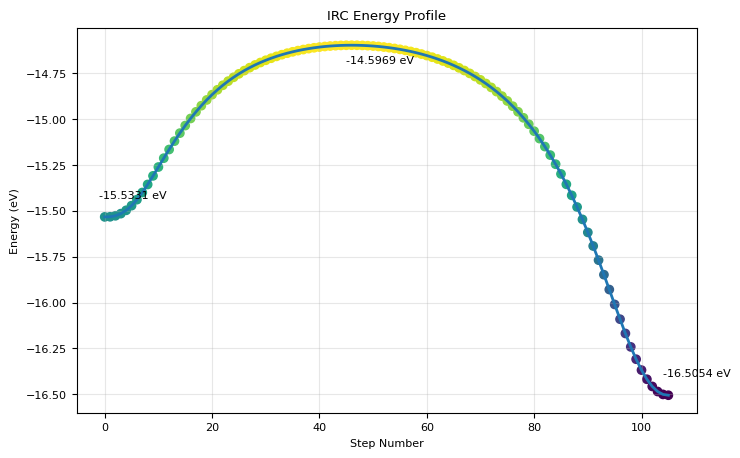

In [8]:
ts_state = opt_structs[0]
_, min1, min2 = run_irc(ts_state, steps=100)

plot_sella_irc("irc_fw.traj", "irc_bw.traj")

In [9]:
check_saddle_point(ts_state), ts_state.get_potential_energy()

({'is_saddle_point': True,
  'n_imaginary_freqs': 5,
  'imaginary_freq_val': np.complex128(123.135450160261j),
  'all_freqs_cm1': array([   0.   +123.135j,    0.    +19.113j,    0.    +17.254j,
            0.    +15.156j,    0.     +0.j   ,    0.     +0.j   ,
            0.     +0.j   ,  343.369  +0.j   ,  485.388  +0.j   ,
          640.87   +0.j   ,  692.807  +0.j   ,  802.482  +0.j   ,
          872.858  +0.j   ,  934.872  +0.j   ,  989.642  +0.j   ,
         1060.77   +0.j   , 1100.267  +0.j   , 1237.743  +0.j   ,
         1306.288  +0.j   , 1451.383  +0.j   , 1559.118  +0.j   ]),
  'n_negative_evals': 1,
  'raw_eigenvalues': array([-2.22700e+00, -5.40000e-02, -4.40000e-02, -3.40000e-02,
         -0.00000e+00,  0.00000e+00,  0.00000e+00,  1.73200e+01,
          3.46110e+01,  6.03360e+01,  7.05110e+01,  9.46030e+01,
          1.11924e+02,  1.28392e+02,  1.43877e+02,  1.65302e+02,
          1.77841e+02,  2.25059e+02,  2.50676e+02,  3.09456e+02,
          3.57102e+02]),
  'lowest_eval

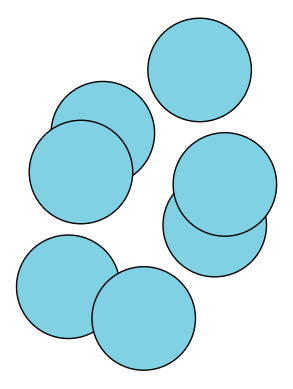

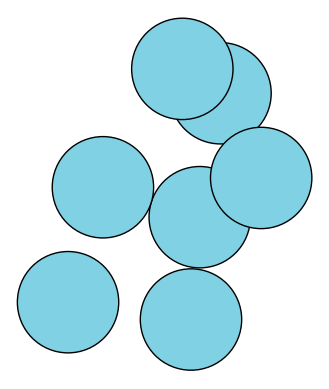

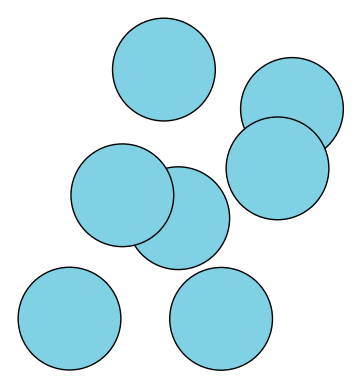

In [36]:
rotation = ""
radii = 0.3
plot_atoms_without_axes(min1, radii=radii, rotation=rotation)
plot_atoms_without_axes(ts_state, radii=radii, rotation=rotation),
plot_atoms_without_axes(min2, radii=radii, rotation=rotation)

In [38]:
ts_state

Atoms(symbols='Ar7', pbc=False, calculator=LennardJones(...))

In [41]:
view(ts_state)

<Popen: returncode: None args: ['/opt/anaconda3/envs/cx/bin/python', '-m', '...>

## 1. Lennard-Jones (LJ) cluster

The first example is a CHARLX evolution of the Lennard-Jones cluster with 13 atoms (LJ-13). The coordinates for the global minimum are loaded from files saved in the directory `data/wales/`. Files for clusters with 13, 31 and 38 atoms are available, other files with clusters up to 150 atoms can be downloaded as a `.tar` file from `https://doye.chem.ox.ac.uk/jon/structures/LJ/tables.150.html`. After loading, additional information is shown: `max_span` (the maximum span of the structure used for conditioning), `dimensions` (number of atoms times three), `symbols` (chemical symbols for the `ase.atoms.Atoms` object) and `rep` (string representation for the destination path of the evolution). Also given is the energy of the structure, calculated by the `evaluate_lj_population_torch()` function, together with a visualiation of the cluster. For an interactive plot, comment in the last line `view(lj_atoms);`.

### Founder

We can now start with the configuration of the evolution. First, we define the randomized LJ-13 cluster from above as the `founder` structure for our evolution.

In [64]:
N_ATOMS = 13 # 13, 31, 38

# Initialize founder structure
lj_cluster_rand, max_span, dimensions, symbols, rep = load_lj_cluster(
    n_atoms=N_ATOMS,
    wales_path=pathlib.Path("clusters/founders"),
    randomize=True,
    random_seed=0,
)

"""
au_cluster_rand, max_span, dimensions, symbols, rep = load_lj_cluster(
    n_atoms=N_ATOMS,
    wales_path=pathlib.Path("clusters/founders"),
    randomize=True,
    random_seed=SEED,
    element="Au",
    name="Au",
)"""


founder = Atoms(symbols, np.reshape(lj_cluster_rand, (-1, 3)))

#plot_atoms_without_axes(founder)

In [19]:
# Detect available device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MULTIPROC = DEVICE == "cpu"  # Disable multiprocessing when using GPU
N_PROC = 16 if MULTIPROC else None

print(f"Using device: {DEVICE}")
print(f"Multiprocessing: {MULTIPROC}")

# Initialize constrainer (no fixed or frozen atoms for a free cluster)
constrainer = IndexConstrainer(
    fix_indices=[],
    freeze_indices=[],
)

# Single optimizer object (used both for relaxation and as TS optimizer)
optimizer = Optimizer(
    founder_atoms=founder,
    constrainer=constrainer,
    calc="Morse",
    optimizer=FIRE,
    fmax=0.001,
    steps=500,
    logfile=None,
    multiproc=MULTIPROC,
    n_proc=N_PROC,
    device=DEVICE,
    e_cutoff=-500,
    progress_bar=True,
)

fixed_indices  = optimizer.fixed_indices
frozen_indices = optimizer.frozen_indices
free_indices   = optimizer.free_indices

# Initialize condition around the origin
condition_obj = OriginCondition(
    n_atoms=optimizer.free_n_atoms,
    target=1.0,
    kwargs={"cond_threshold": max_span},
)

# Initialize evolutionary algorithm
es = CHARLX
es_config = dict(
    x0=optimizer.free_positions.to(DEVICE),
    constrainer=constrainer,
    optimizer=optimizer,
    conditions=(condition_obj, GpuKNNNoveltyCondition()),
    popsize=20,
    n_gens=10,
    sigma_init=1.0,
    selection_pressure=20.0,
    elite_ratio=0.15,
    crossover_ratio=0.125,
    mutation_rate=0.05,
    diff_batch_size=256,
    diff_max_epoch=1000,
    buffer_size=1000,
    is_genetic_algorithm=True,
    adaptive_selection_pressure=True,
    readaptation=False,
    forget_best=False,
    device=DEVICE,
)

# Initialize neural network
nn = "MLP"
nn_config = dict(
    num_hidden=96,
    num_layers=8,
    activation="LeakyReLU",
    num_params=optimizer.dimensions,
    num_conditions=len(es_config["conditions"]),
)

# Initialize diffusion model
diff = "GGDDIM"
diff_config = dict(
    num_steps=5000,
    lamba_range=1.0,
    geometry="radial",
    axis=None,
    lower_threshold=0.0,
    upper_threshold=max_span * 1.5,
    diff_origin=[0.0, 0.0, 0.0],
    overlap_penalty=True,
    train_on_penalty=True,
)

# OBJECTIVE
objective = CorrectedApplyLimitsObjective(
    foo_module="condevofm.atoms.evaluate",
    foo="evaluate_population_with_calc",
    foo_kwargs={"obj_params": optimizer.encode_params(),
                "evaluate_atoms": "get_potential_energy"
                },
    maximize=True,
    dim=optimizer.dimensions,
)


Using device: cuda
Multiprocessing: False


In [20]:
# Define destination path for output data
dst = f"output/{rep}"
dst += f"_P-{es_config['popsize']}"
dst += f"_G-{es_config['n_gens']}"
dst += f"_F-{optimizer.fmax}"
dst += f"_S-{optimizer.steps}"
dst += f"_U-{diff_config['upper_threshold']:.3f}"


In [21]:
# Remove old folder before new evolution
shutil.rmtree(dst, ignore_errors=True)

# Execute CHARLX evolution
evo = run_evo(
    generations=es_config["n_gens"],
    es=es,
    es_config=es_config,
    nn=nn,
    nn_config=nn_config,
    diff=diff,
    diff_config=diff_config,
    objective=objective,
    dst=dst,
    params={"save_diffusion": False},
)


# Loading Objective:
<class 'condevofm.utils.run.CorrectedApplyLimitsObjective'> True
-  {"dim": 39, "foo_module": "condevofm.atoms.evaluate", "foo_kwargs": {"obj_params": {"founder_atoms": "{\"numbers\": {\"__ndarray__\": [[13], \"int64\", [79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79]]}, \"positions\": {\"__ndarray__\": [[13, 3], \"float64\", [-0.428499794284629, -0.49828615663862164, -1.7013985743596773, -0.19979710057191227, 1.598784762410794, 0.8331323726690198, 1.1847174381394625, 0.31192043273282566, -1.0442142633377391, 1.0813332791392645, 0.11269775204546528, 1.1489449795386464, 0.6219370501216992, -1.4811731897416949, 0.1336710683957333, 1.0420980885268694, -0.6362989297258376, -0.5338030061734236, -0.7254064722399862, -0.5747208756668536, -0.14484534638636432, -0.0697898237280881, -0.5387330306925501, -1.5446476542951022, -0.9356658191588881, -0.26309185204285324, -1.1069207327728727, 1.0663574228694659, -0.460878059649808, 0.42174169513621274, 0.5514634303128284, -1.2

Training	: 100%|██████████| 1000/1000 [00:04<00:00, 219.52epoch/s, loss=0.199]

  { "Generation": 0, "Max-Fitness": 14.0031644925751, "Avg-Fitness": 8.535574338949377, "Model-Loss": 0.19930640973324226}



Training	: 100%|██████████| 1000/1000 [00:04<00:00, 216.08epoch/s, loss=0.209]

  { "Generation": 1, "Max-Fitness": 26.011670754693377, "Avg-Fitness": 16.247489840306695, "Model-Loss": 0.2094033319635217}


...


Training	: 100%|██████████| 1000/1000 [00:04<00:00, 226.88epoch/s, loss=0.191]


  { "Generation": 8, "Max-Fitness": 36.343955779667255, "Avg-Fitness": 27.582335194744566, "Model-Loss": 0.19078661154315046}


Training	: 100%|██████████| 1000/1000 [00:04<00:00, 226.44epoch/s, loss=0.148]

  { "Generation": 9, "Max-Fitness": 36.343955779667255, "Avg-Fitness": 29.813335453935043, "Model-Loss": 0.14766300913057462}


  { "Generation": 9, "Max-Fitness": 36.343955779667255, "Avg-Fitness": 29.813335453935046, "Model-Loss": 0.14766300913057462}


### View results

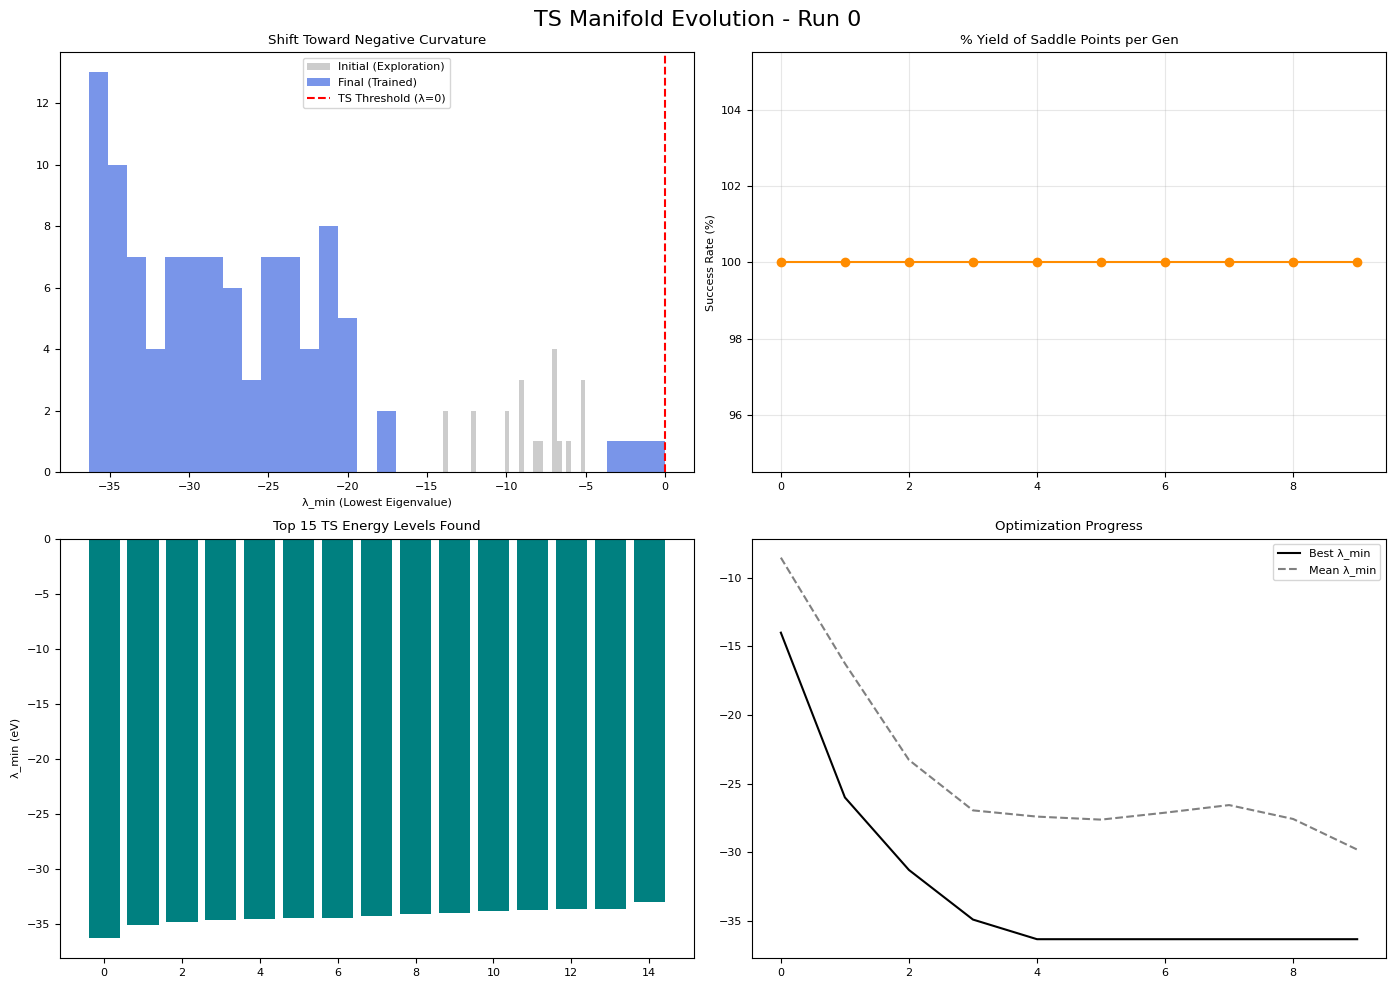

In [22]:
# Analyze ES convergence and minima found
#h5_file = "output/LJ-7_P-32_G-10_F-0.001_S-1000_U-2.337/ES_CHARLX-objective_evaluate_population_with_calc.h5"  # evo[0]  # First element of evo tuple is the h5_filename
#h5_file = "output/LJ-7_P-16_G-15_F-0.001_S-1000_U-2.337/ES_CHARLX-objective_minimize_eigenval.h5"
h5_file = evo[0]
run_id = evo[1]   # Second element is the run_id


convergence_analysis = analyze_ts_performance_robust(
    h5_file, 
    run_id=run_id,
    #obj_params=ts_optimizer.encode_params()
)


Analyzing last 10/10 generations: gen_0 → gen_9

Fitness summary:
  mean: 24.114456840443662
  std : 9.040119235140414
  best: 36.343955779667255
  worst: 2.0772967164464436e-05


Energy: 100%|██████████| 200/200 [00:00<00:00, 576.68it/s]



Energy groups found: 183
1      -36.343956         6          3.00%
2      -35.135157         3          1.50%
3      -35.134769         6          3.00%
4      -34.913117         1          0.50%
5      -34.902226         1          0.50%
6      -34.657209         1          0.50%
7      -34.597435         4          2.00%
8      -34.526943         1          0.50%
9      -34.480725         1          0.50%
10     -34.292670         1          0.50%
11     -34.136293         1          0.50%
12     -34.056507         1          0.50%
13     -34.039381         1          0.50%
14     -33.839293         1          0.50%
15     -33.729590         1          0.50%
16     -33.683881         1          0.50%
17     -33.662726         1          0.50%
18     -33.648620         1          0.50%
19     -33.056871         1          0.50%
20     -33.043310         1          0.50%
21     -32.900970         1          0.50%
22     -32.666617         1          0.50%
23     -32.351791         1 

Saddle: 100%|██████████| 200/200 [00:27<00:00,  7.29it/s]



  saddle fraction: 0.005


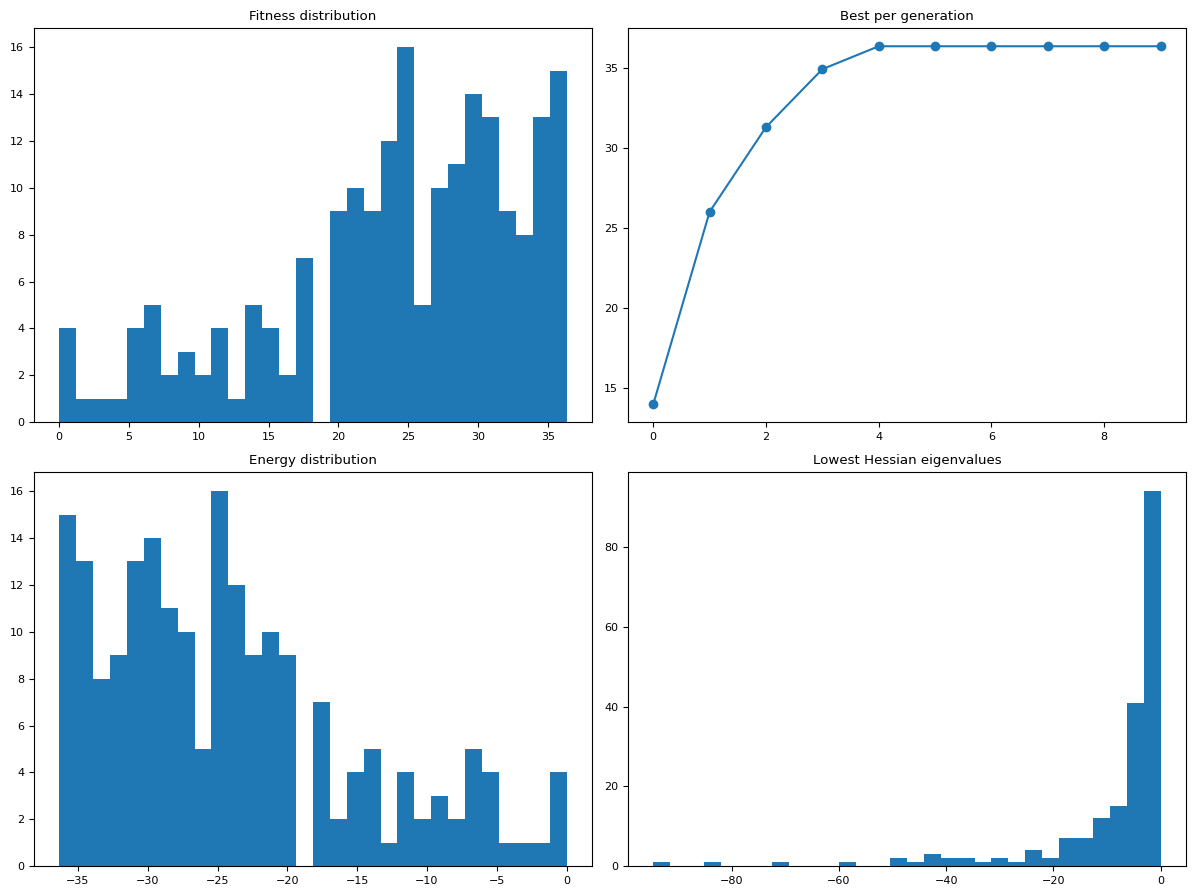

In [73]:
results, records_df = analyze_es_results(
    h5_filename=h5_file,
    run_id=0,
    last_gen_percent=1.0,
    obj_params=optimizer.encode_params(),
    energy_tolerance=1e-5,
    #extra_metrics={
    #    "n_atoms": lambda a: len(a),
    #    "com_z": lambda a: a.get_center_of_mass()[2],
    #},
)

In [66]:
records_df.sort_values("energy").head(20)

,idx,energy,atoms,lowest_eigenvalue,is_saddle
0,0,-36.343956,"(Atom('Au', [np.float64(0.05278844022205914), ...",-0.557716,False
1,1,-35.135157,"(Atom('Au', [np.float64(-0.30398960840739475),...",-0.523341,False
2,2,-35.134769,"(Atom('Au', [np.float64(0.4621048268826669), n...",-0.524342,False
4,4,-34.902226,"(Atom('Au', [np.float64(0.3863047861325776), n...",-1.998968,False
17,17,-34.657209,"(Atom('Au', [np.float64(0.6477622186643733), n...",-8.989669,False
6,6,-34.480725,"(Atom('Au', [np.float64(0.2959691431678695), n...",-7.264833,False
18,18,-34.136293,"(Atom('Au', [np.float64(-0.10509897287639718),...",-0.655021,False
8,8,-31.095145,"(Atom('Au', [np.float64(0.18862886237421603), ...",-16.485288,False
19,19,-30.937340,"(Atom('Au', [np.float64(0.06931408574782785), ...",-3.358240,False
7,7,-30.932281,"(Atom('Au', [np.float64(0.5375336352589392), n...",-3.422896,False


np.float64(-36.343955779667255)

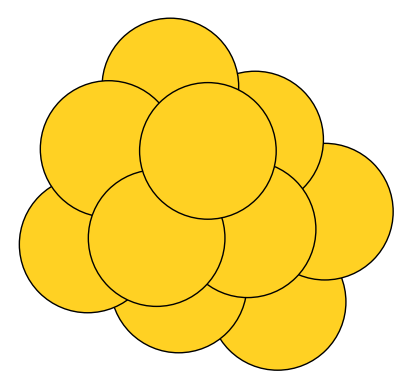

In [72]:
at = records_df.sort_values("energy").iloc[0]
plot_atoms_without_axes(at["atoms"], radii=0.5, rotation="90y")
at["energy"]

In [ ]:
view(at["atoms"])

<Popen: returncode: None args: ['/home/e12009247/miniconda3/envs/cx/bin/pyth...>

usage: ase [-h] [--version] [-T]
           {help,info,test,gui,db,run,band-structure,build,dimensionality,eos,ulm,find,nebplot,convert,reciprocal,completion,diff,exec}
           ...
ase: error: TclError: no display name and no $DISPLAY environment variable
To get a full traceback, use: ase -T gui ...
